In [4]:
from google.colab import drive
import os

# 1. Driveをマウント
drive.mount('/content/drive')

# 2. ログ保存用のフォルダを作成
LOG_DIR = "/content/drive/MyDrive/Research_Logs"
os.makedirs(LOG_DIR, exist_ok=True)

print(f"✅ ログ保存先: {LOG_DIR}")

Mounted at /content/drive
✅ ログ保存先: /content/drive/MyDrive/Research_Logs


In [2]:
%pip install rank_bm25
%pip install xopen

from pathlib import Path
import sys
import torch
from datasets import load_dataset
from datetime import datetime
import xopen

import huggingface_hub
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
huggingface_hub.login(hf_token)


# 以下自作モジュール
module_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/my_modules"
if module_path not in sys.path:
    sys.path.append(module_path)

from DynamicScalingLlamaAttention import DynamicScalingLlamaAttention
from ScalingController import ScalingController
from get_model_safe import get_model_safe, test_patched_model_sanity, remove_cache
from main_inference import main_inference
from run_eval import run_eval_exact_match
from analyze_log import ExperimentAnalyzer


if 'CACHED_MODEL' not in globals():
    CACHED_MODEL = None
    CACHED_TOKENIZER = None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.4/132.4 kB 12.4 MB/s eta 0:00:00


ModuleNotFoundError: No module named 'DynamicScalingLlamaAttention'

In [ ]:
from xopen import xopen
import json
import gc
import torch
import torch.nn as nn
from tqdm import tqdm
import random

random.seed(0)

import sys

def confirmation():
    """実行前にユーザーの確認を求める"""
    print("\n" + "!" * 30)
    print("警告: 書き出しモードが 'a' (追記) です。")
    print("既存のファイルにデータが追加されますが、よろしいですか？")
    print("!" * 30 + "\n")

    answer = input("実行する場合は 'yes' と入力してください: ").strip().lower()

    if answer != 'yes':
        print("\n[中止] 実行がキャンセルされました。")
        # Jupyterでセルを止める最もクリーンな方法
        raise KeyboardInterrupt("User cancelled the execution.")

    print("\n[開始] 実験を実行します...\n")

In [ ]:
from datasets.formatting.formatting import TypeVar
from typing import List, Optional, Type
from pydantic.dataclasses import dataclass

from rank_bm25 import BM25Okapi

PROMPTS_ROOT = Path("/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/lost_in_the_middle/prompts")
T = TypeVar("T")

@dataclass(frozen=True)
class Document:
    title: str
    text: str
    id: Optional[str] = None
    score: Optional[float] = None
    hasanswer: Optional[bool] = None
    isgold: Optional[bool] = None
    original_retrieval_index: Optional[int] = None

    @classmethod
    def from_dict(cls: Type[T], data: dict) -> T:
        data = deepcopy(data)
        if not data:
            raise ValueError("Must provide data for creation of Document from dict.")
        id = data.pop("id", None)
        score = data.pop("score", None)
        isgold = data.pop("isgold", None)
        # Convert score to float if it's provided.
        if score is not None:
            score = float(score)
        return cls(**dict(data, id=id, score=score, isgold=isgold))

def get_qa_prompt(
    question: str, documents: List[Document], mention_random_ordering: bool, query_aware_contextualization: bool
):
    if not question:
        raise ValueError(f"Provided `question` must be truthy, got: {question}")
    if not documents:
        raise ValueError(f"Provided `documents` must be truthy, got: {documents}")

    if mention_random_ordering and query_aware_contextualization:
        raise ValueError("Mentioning random ordering cannot be currently used with query aware contextualization")

    if mention_random_ordering:
        prompt_filename = "qa_ordered_randomly.prompt"
    elif query_aware_contextualization:
        prompt_filename = "qa_with_query_aware_contextualization.prompt"
    else:
        prompt_filename = "qa.prompt"

    with open(PROMPTS_ROOT / prompt_filename) as f:
        prompt_template = f.read().rstrip("\n")

    # Format the documents into strings
    formatted_documents = []
    for document_index, document in enumerate(documents):
        formatted_documents.append(f"Document [{document_index+1}](Title: {document.title}) {document.text}")
    return prompt_template.format(question=question, search_results="\n".join(formatted_documents))

def reorder_bm25(documents, question):
    """
    BM25スコアに基づいてドキュメントを降順に並び替える
    """
    if not documents:
        return []

    # 各ドキュメントを分割、小文字にしてリストで文章を格納
    tokenized_corpus = [doc.text.lower().split() for doc in documents]
    tokenized_query = question.lower().split()

    # bm25
    bm25 = BM25Okapi(tokenized_corpus)
    doc_scores = bm25.get_scores(tokenized_query)

    # スコアの降順（reverse=True）に並び替え
    reordered_docs = [doc for _, doc in sorted(zip(doc_scores, documents), reverse=True, key=lambda x: x[0])]

    return reordered_docs

In [ ]:
import torch

def run_inference(
  prompt,
  model,
  tokenizer
):
  inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(model.device)
  seq_len = inputs.input_ids.shape[1]

  with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=100,
        temperature=0.0,
        do_sample=False
    )

  generated_text = tokenizer.decode(output[0][seq_len:], skip_special_tokens=True)
  return generated_text.strip()

def run_inference_scaled(
  prompt,
  model,
  tokenizer
):
  inputs = tokenizer(prompt, return_tensors="pt", padding=True).to(model.device)
  seq_len = inputs.input_ids.shape[1]

  scale_map = torch.full((1, seq_len), 1.0, device=model.device, dtype=torch.float16)
  model.config.current_scale_map = scale_map

  with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=100,
        temperature=0.0,
        do_sample=False
    )

  generated_text = tokenizer.decode(output[0][seq_len:], skip_special_tokens=True)
  return generated_text.strip()

In [ ]:
# 既存研究の実装コード

from xopen import xopen
from copy import deepcopy
from tqdm import tqdm
import json

NQ_path = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"
OUTPUT_PATH = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/result_scaled.jsonl"

MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"

def main():
  model, tokenizer = get_model_safe(MODEL_NAME)
  with xopen(NQ_path, "r") as fin, xopen(OUTPUT_PATH, "a") as fout:
    for line in tqdm(fin):
      input = json.loads(line)
      question = input["question"]

      documents = []
      for ctx in deepcopy(input["ctxs"]):
        documents.append(Document.from_dict(ctx))
      if not documents: raise ValueError(f"Did not find any documents: {input}")
      documents = reorder_bm25(documents, question)

      prompt = get_qa_prompt(question, documents, mention_random_ordering=False, query_aware_contextualization=False)
      result = run_inference_scaled(prompt, model, tokenizer)

      output_dict = {
          "question": question,
          "answer": result,
          "prompt": prompt,
      }
      fout.write(json.dumps(output_dict) + "\n")
      fout.flush()

if __name__ == "__main__":
  main()

In [ ]:
# baselineの実装コード

from xopen import xopen
from copy import deepcopy
from tqdm import tqdm
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from itertools import islice

NQ_path = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"
OUTPUT_PATH = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/test_batch_baseline.jsonl"

MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"
BATCH_SIZE = 5


def main():
  tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
  model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        device_map="auto",
        attn_implementation="eager",
        dtype=torch.float16,
        use_cache=True,
        trust_remote_code=True
  )

  with xopen(NQ_path, "r") as fin, xopen(OUTPUT_PATH, "a") as fout:
    for i, line in enumerate(tqdm(fin)):
      if i >= 50: break

      input = json.loads(line)
      question = input["question"]

      documents = []
      for ctx in deepcopy(input["ctxs"]):
        documents.append(Document.from_dict(ctx))
      if not documents: raise ValueError(f"Did not find any documents: {input}")
      documents = reorder_bm25(documents, question)

      prompt = get_qa_prompt(question, documents, mention_random_ordering=False, query_aware_contextualization=False)
      result = run_inference(prompt, model, tokenizer)

      output_dict = {
          "question": question,
          "answer": result,
          "prompt": prompt,
      }
      fout.write(json.dumps(output_dict) + "\n")
      fout.flush()

if __name__ == "__main__":
  confirmation()
  main()

SyntaxError: invalid syntax (ipython-input-1545732046.py, line 8)

In [ ]:
import torch
import gc
import os
from xopen import xopen
from copy import deepcopy
from tqdm import tqdm
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from itertools import islice
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


NQ_path = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"
OUTPUT_PATH = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/test_batch_baseline.jsonl"

MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"
BATCH_SIZE = 8



# デバッグ用：メモリ使用量を表示する関数
def print_vram_usage(step_name=""):
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    max_allocated = torch.cuda.max_memory_allocated() / 1024**3
    print(f"[{step_name}]")
    print(f"  Allocated: {allocated:.2f} GB")
    print(f"  Reserved:  {reserved:.2f} GB")
    print(f"  Peak:      {max_allocated:.2f} GB (since last reset)")
    print("-" * 30)

def main():
    # 1. 環境変数の設定（断片化対策）
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512"

    with xopen(NQ_path, "r") as fin, xopen(OUTPUT_PATH, "a") as fout:
        print_vram_usage("Before Loading Model")

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"

        model = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            device_map="auto",
            attn_implementation="eager",
            torch_dtype=torch.float16,
            use_cache=True,
            trust_remote_code=True
        )

        print_vram_usage("After Loading Model") # モデルの重み分が表示される

        phar = tqdm(unit=f" {BATCH_SIZE} batch")
        try:
            while True:
                lines = list(islice(fin, BATCH_SIZE))
                if not lines: break

                batch_data = [json.loads(line) for line in lines]
                batch_question = [data["question"] for data in batch_data]

                # 文書の並び替えなどの処理
                batch_documents = []
                for data in batch_data:
                    documents = [Document.from_dict(ctx) for ctx in data["ctxs"]] # deepcopyを避ける
                    batch_documents.append(documents)

                batch_documents = [reorder_bm25(docs, q) for q, docs in zip(batch_question, batch_documents)]
                batch_prompt = [get_qa_prompt(q, docs, mention_random_ordering=False, query_aware_contextualization=False) for q, docs in zip(batch_question, batch_documents)]

                # 推論前のピークメモリ記録をリセット
                torch.cuda.reset_peak_memory_stats()
                print_vram_usage("Before Inference")

                # 推論実行
                results = run_inference(batch_prompt, model, tokenizer)

                # 推論直後（一番メモリが膨らんでいるはずのタイミング）
                print_vram_usage("After Inference (Peak Check)")


                for data, result in zip(batch_data, results):
                    output_line = json.dumps(data)
                    fout.write(output_line + "\n")
                    fout.flush()

                phar.update(len(lines))

                print_vram_usage("After Cache Clear")

            phar.close()

        finally:
            # 終了処理
            if 'model' in locals(): del model
            gc.collect()
            torch.cuda.empty_cache()

main()

[Before Loading Model]
  Allocated: 0.00 GB
  Reserved:  0.00 GB
  Peak:      0.00 GB (since last reset)
------------------------------


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

[After Loading Model]
  Allocated: 12.55 GB
  Reserved:  12.57 GB
  Peak:      12.55 GB (since last reset)
------------------------------


0 8 batch [00:00, ? 8 batch/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


...

544 8 batch [14:03,  1.44s/ 8 batch]

[After Inference (Peak Check)]
  Allocated: 12.56 GB
  Reserved:  75.63 GB
  Peak:      51.28 GB (since last reset)
------------------------------
[After Cache Clear]
  Allocated: 12.56 GB
  Reserved:  75.63 GB
  Peak:      51.28 GB (since last reset)
------------------------------
[Before Inference]
  Allocated: 12.56 GB
  Reserved:  75.63 GB
  Peak:      12.56 GB (since last reset)
------------------------------


552 8 batch [14:15,  1.46s/ 8 batch]

[After Inference (Peak Check)]
  Allocated: 12.56 GB
  Reserved:  75.63 GB
  Peak:      54.73 GB (since last reset)
------------------------------
[After Cache Clear]
  Allocated: 12.56 GB
  Reserved:  75.63 GB
  Peak:      54.73 GB (since last reset)
------------------------------
[Before Inference]
  Allocated: 12.56 GB
  Reserved:  75.63 GB
  Peak:      12.56 GB (since last reset)
------------------------------


KeyboardInterrupt: 

In [ ]:
# batched baselineの実装コード

from xopen import xopen
from copy import deepcopy
from tqdm import tqdm
import json
from transformers import AutoTokenizer, AutoModelForCausalLM
from itertools import islice

NQ_path = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"
OUTPUT_PATH = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/test_batch_baseline.jsonl"

MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"
BATCH_SIZE = 10


def main():
  with xopen(NQ_path, "r") as fin, xopen(OUTPUT_PATH, "a") as fout:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    if tokenizer.pad_token is None:
      tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    model = AutoModelForCausalLM.from_pretrained(
          MODEL_NAME,
          device_map="auto",
          attn_implementation="eager",
          dtype=torch.float16,
          use_cache=True,
          trust_remote_code=True
    )

    phar = tqdm(unit=f"{BATCH_SIZE} batch")
    try:
      while True:
        lines = list(islice(fin, BATCH_SIZE))
        if not lines: break

        batch_data = [json.loads(line) for line in lines]
        batch_question = [data["question"] for data in batch_data]

        batch_documents = []
        for data in batch_data:
          documents = []
          for ctx in deepcopy(data["ctxs"]):
            documents.append(Document.from_dict(ctx))
          batch_documents.append(documents)
        batch_documents = [reorder_bm25(documents, question) for question, documents in zip(batch_question, batch_documents)]

        batch_prompt = [get_qa_prompt(question, documents, mention_random_ordering=False, query_aware_contextualization=False) for question, documents in zip(batch_question, batch_documents)]

        results = run_inference(batch_prompt, model, tokenizer)
        gc.collect()
        torch.cuda.empty_cache()

        for data, result in zip(batch_data, results):
          output_line = json.dumps(data)
          fout.write(output_line + "\n")
          fout.flush()

        phar.update(len(lines))
      phar.close()

    finally:
      if 'model' in locals():
        del model
      if 'inputs' in locals():
        del inputs
      if 'outputs' in locals():
        del outputs

      gc.collect()
      torch.cuda.empty_cache()


if __name__ == "__main__":
  confirmation()
  main()


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
警告: 書き出しモードが 'a' (追記) です。
既存のファイルにデータが追加されますが、よろしいですか？
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

実行する場合は 'yes' と入力してください: yes

[開始] 実験を実行します...



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

010 batch [00:00, ?10 batch/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
1010 batch [00:14,  1.47s/10 batch]

OutOfMemoryError: CUDA out of memory. Tried to allocate 17.51 GiB. GPU 0 has a total capacity of 79.32 GiB of which 10.78 GiB is free. Process 97880 has 68.53 GiB memory in use. Of the allocated memory 40.90 GiB is allocated by PyTorch, and 27.13 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import torch
import gc


def flush_memory():
    # 1. Python上のモデルやテンソルの参照を明示的に削除
    # （ループ内で model = ... としている場合は del model が必要）
    # del variables_name

    # 2. Pythonのガベージコレクションを強制実行
    gc.collect()

    # 3. PyTorchのキャッシュを解放してGPUに返却
    torch.cuda.empty_cache()

    # 4. (任意) 完全にリセットされたか確認
    print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
    print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

flush_memory()

0 8 batch [10:03, ? 8 batch/s]

Allocated: 30.31 GB
Reserved:  30.88 GB


In [ ]:
# アテンション重みの実装コード

from xopen import xopen
from copy import deepcopy
from tqdm import tqdm
import json
import random

random.seed(0)

NQ_path = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"
OUTPUT_PATH = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/result_reordering_by_attnmap.jsonl"

SHUFFLE_NUM = 20

MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"

def main():
  model, tokenizer = get_model_safe(MODEL_NAME)
  model.config.current_scale_map = None
  with xopen(NQ_path, "r") as fin, xopen(OUTPUT_PATH, "a") as fout:
    for i, line in enumerate(tqdm(fin)):
      if i < 101 or i >= 200 : continue
      input = json.loads(line)
      question = input["question"]
      answers = input["answers"]

      documents = []
      for ctx in deepcopy(input["ctxs"]):
        documents.append(Document.from_dict(ctx))
      if not documents: raise ValueError(f"Did not find any documents: {input}")

      attnmaps = []
      for i in range(SHUFFLE_NUM):
        attnmap = get_attnmap(question, documents, model, tokenizer, i) # 各ドキュメントのattnmapの平均を取得
        attnmaps.append(attnmap)

      # attnmapsからインデックスを作成
      documents = reorder_attnmap_index(documents, attnmaps)
      prompt = get_qa_prompt(question, documents, mention_random_ordering=False, query_aware_contextualization=False)

      result = run_inference(prompt, model, tokenizer)

      output_dict = {
          "question": question,
          "model_output": result,
          "answers": answers,
          "prompt": prompt,
          "attnmaps": attnmaps,
          "gold_at": 0,
      }
      fout.write(json.dumps(output_dict) + "\n")
      fout.flush()

if __name__ == "__main__":
  confirmation()
  main()


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
警告: 書き出しモードが 'a' (追記) です。
既存のファイルにデータが追加されますが、よろしいですか？
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

実行する場合は 'yes' と入力してください: yes

[開始] 実験を実行します...

✅ Model already loaded. Using cached model.


2655it [3:29:06,  4.73s/it]


In [ ]:
import torch

def get_qa_prompt_reorder(question, documents, trial_order):
  prompt_filename = "qa.prompt"

  with open(PROMPTS_ROOT / prompt_filename) as f:
    prompt_template = f.read().rstrip("\n")

  shifted_documents = documents[trial_order:] + documents[:trial_order]

  formatted_documents = []
  for document_index, document in enumerate(shifted_documents):
    formatted_documents.append(f"Document [{document_index+1}](Title: {document.title}) {document.text}")
  prompt = prompt_template.format(question=question, search_results="\n".join(formatted_documents))

  doc_positions = []
  for formatted_document in formatted_documents:
    start_idx = prompt.find(formatted_document)
    end_idx = start_idx + len(formatted_document)
    doc_positions.append({
        "start": start_idx,
        "end": end_idx
        })
  return prompt, doc_positions

def get_attnmap(question, documents, model, tokenizer, trial_order):
  """各文書のトークンに対するアテンション重みの取得を行う"""
  # プロンプトの作成と位置取得
  prompt, doc_positions = get_qa_prompt_reorder(question, documents, trial_order)

  # トークナイズ
  inputs = tokenizer(
      prompt,
      return_tensors="pt",
      return_offsets_mapping=True,
  ).to(model.device)
  offset_mapping = inputs.pop("offset_mapping")[0]

  # Hookの設定
  layer_attns = {}
  target_layer_indices = range(14, 20) # 15層(index 14)から20層(index 19)
  def hook_fn(layer_idx):
    def fn(module, input, output):
      q = module.last_q_scaled
      k = module.last_k_scaled

      d_k = q.size(-1)
      scores = torch.matmul(q, k.transpose(-2, -1)) / (d_k ** 0.5)

      attn_weights = torch.nn.functional.softmax(scores, dim=-1)
      layer_attns[layer_idx] = attn_weights.detach().cpu()[0]
    return fn

  hooks = []
  for i in target_layer_indices:
    h = model.model.layers[i].self_attn.register_forward_hook(hook_fn(i))
    hooks.append(h)

  # Prefill
  try:
    with torch.no_grad():
      _ = model(**inputs)

    # 各文書の重みを集計
    all_selected_attn = torch.stack(list(layer_attns.values())) # [layers, heads, 1, seq_len]
    avg_attn_matrix = all_selected_attn.mean(dim=0).mean(0) # [1, seq_len]

    current_trial_scores = []
    for pos in doc_positions:
      start_char, end_char = pos["start"], pos["end"]

      token_indices = []
      for i , (s,e) in enumerate(offset_mapping):
        if s == e == 0: continue
        if e >= start_char and s <= end_char:
          token_indices.append(i)

      score = avg_attn_matrix[0, token_indices].sum().item()
      current_trial_scores.append(score)
    num_docs = len(documents)
    original_ordered_scores = [0.0] * num_docs
    for j, score in enumerate(current_trial_scores):
      original_ordered_scores[j] = score

  finally:
    for h in hooks:
      h.remove()

  return original_ordered_scores

def reorder_attnmap_index(documents, attnmaps):
    """
    複数回の試行で得られたアテンションスコアを集計し、
    ドキュメントをアテンションの大きい順に並び替える。
    """
    if not documents or not attnmaps:
        return documents

    num_docs = len(documents)

    total_scores = [0.0] * num_docs
    for trial_scores in attnmaps:
        for i, score in enumerate(trial_scores):
            total_scores[i] += score

    sorted_pairs = sorted(
        zip(documents, total_scores),
        key=lambda x: x[1],
        reverse=True
    )

    reordered_docs = [doc for doc, score in sorted_pairs]

    return reordered_docs


2655it [00:00, 5967.90it/s]


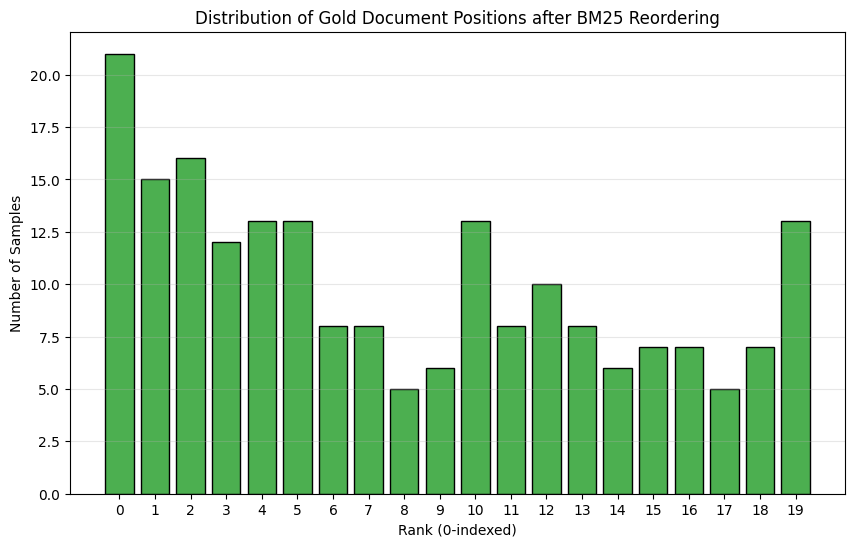

In [ ]:
import matplotlib.pyplot as plt
from copy import deepcopy

NQ_path = f"/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"

def plot_gold_position_histogram(gold_positions, total_docs_count):
    """
    Gold文書の位置（インデックス）のリストを受け取り、ヒストグラムを表示する
    """
    plt.figure(figsize=(10, 6))

    # ヒストグラムの描画
    plt.hist(gold_positions, bins=range(total_docs_count + 1),
             align='left', rwidth=0.8, color='#4CAF50', edgecolor='black')

    plt.title('Distribution of Gold Document Positions after BM25 Reordering')
    plt.xlabel('Rank (0-indexed)')
    plt.ylabel('Number of Samples')
    plt.xticks(range(total_docs_count))
    plt.grid(axis='y', alpha=0.3)

    plt.show()

def main():
    all_gold_positions = [] # Gold文書のインデックスを保存する用
    total_docs_per_sample = 20 # ヒストグラムのX軸の範囲を決めるため

    with xopen(NQ_path, "r") as fin:
        for i, line in enumerate(tqdm(fin)):
            if i > 200: continue
            input = json.loads(line)
            question = input["question"]

            documents = []
            for ctx in deepcopy(input["ctxs"]):
                doc = Document.from_dict(ctx)
                documents.append(doc)

            documents = reorder_bm25(documents, question)

            for idx, doc in enumerate(documents):
                if getattr(doc, 'isgold', False):
                    all_gold_positions.append(idx)

    # 最後にヒストグラムを表示
    if all_gold_positions:
        plot_gold_position_histogram(all_gold_positions, total_docs_per_sample)
    else:
        print("Gold文書が一つも見つかりませんでした。Documentの属性名を確認してください。")

if __name__ == "__main__":
    main()

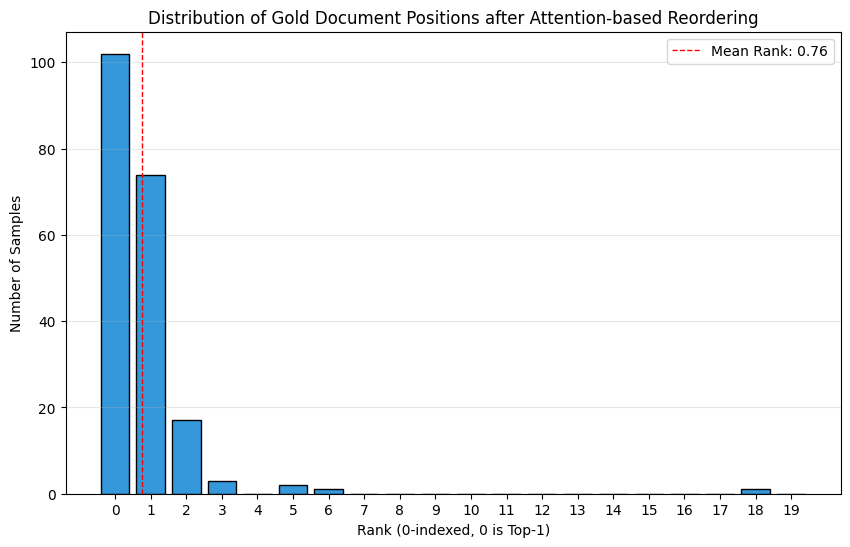

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot_attn_gold_distribution(jsonl_path, total_docs_count=20):
    """
    JSONLファイルからattnmapsを読み込み、Gold文書の順位分布をプロットする
    """
    gold_positions = []

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)

            # 1. attnmapsをnumpy配列に変換 [SHUFFLE_NUM, num_docs]
            # 例: [20, 20]
            attn_scores = np.array(data["attnmaps"])

            # 2. 全試行の平均スコアを計算 [num_docs]
            avg_scores = attn_scores.mean(axis=0)

            # 3. スコアの降順順位を取得
            # argsortは昇順なので、マイナスを付けて降順にし、
            # さらに「何番目に大きいか」の順位表を作成する
            ranks = np.argsort(-avg_scores) # スコアが大きい順のインデックスリスト

            # 4. 元のGold文書(index 0)が ranks の中のどこにあるかを探す
            # np.whereの結果はタプルなので[0][0]で値を取り出す
            gold_rank = np.where(ranks == 0)[0][0]

            gold_positions.append(gold_rank)

    # ヒストグラムの描画
    plot_attn_reordered_histogram(gold_positions, total_docs_count)

    return gold_positions

def plot_attn_reordered_histogram(gold_positions, total_docs_count):
    """
    アテンション再配置後のGold文書の位置を表示する
    """
    plt.figure(figsize=(10, 6))

    # ヒストグラムの描画
    plt.hist(gold_positions, bins=range(total_docs_count + 1),
             align='left', rwidth=0.8, color='#3498db', edgecolor='black')

    plt.title('Distribution of Gold Document Positions after Attention-based Reordering')
    plt.xlabel('Rank (0-indexed, 0 is Top-1)')
    plt.ylabel('Number of Samples')
    plt.xticks(range(total_docs_count))
    plt.grid(axis='y', alpha=0.3)

    # 平均順位などの統計情報をテキストで追加
    mean_rank = np.mean(gold_positions)
    plt.axvline(mean_rank, color='red', linestyle='dashed', linewidth=1, label=f'Mean Rank: {mean_rank:.2f}')
    plt.legend()

    plt.show()

# 実行例
gold_ranks = analyze_and_plot_attn_gold_distribution(OUTPUT_PATH)

In [6]:
import json
import regex
import string
import numpy as np
import matplotlib.pyplot as plt
from typing import List

# --- 提供された評価ロジック ---
def normalize_answer(s: str) -> str:
    def remove_articles(text):
        return regex.sub(r"\b(a|an|the)\b", " ", text)
    def white_space_fix(text):
        return " ".join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def best_subspan_em(prediction: str, ground_truths: List[str]) -> float:
    normalized_prediction = normalize_answer(prediction)
    for ground_truth in ground_truths:
        normalized_ground_truth = normalize_answer(ground_truth)
        if normalized_ground_truth.lower() in normalized_prediction.lower():
            return 1.0
    return 0.0

# --- 分析・図示用関数 ---
def plot_accuracy_by_gold_rank(jsonl_path, total_docs_count=20):
    """
    Gold文書の順位ごとの正解率を集計し、棒グラフで表示する
    """
    # 順位ごとの「正解数」と「サンプル数」を保持する配列
    rank_correct_counts = np.zeros(total_docs_count)
    rank_total_counts = np.zeros(total_docs_count)

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)

            # 1. アテンションスコアからGold(index 0)の順位を計算
            attn_scores = np.array(data["attnmaps"])
            avg_scores = attn_scores.mean(axis=0)
            ranks = np.argsort(-avg_scores)
            gold_rank = np.where(ranks == 0)[0][0]

            # 2. 正解判定 (best_subspan_emを使用)
            prediction = data["model_output"]
            ground_truths = data["answers"]
            is_correct = best_subspan_em(prediction, ground_truths)

            # 3. 集計
            rank_total_counts[gold_rank] += 1
            if is_correct == 1.0:
                rank_correct_counts[gold_rank] += 1

    # 4. 順位ごとの正解率を計算 (サンプルが0の順位は0%とする)
    accuracies = np.divide(rank_correct_counts, rank_total_counts,
                           out=np.zeros_like(rank_correct_counts),
                           where=rank_total_counts != 0)

    # --- 図示処理 ---
    plt.figure(figsize=(12, 6))

    # 棒グラフ
    bars = plt.bar(range(total_docs_count), accuracies, color='#f39c12', edgecolor='black', alpha=0.8)

    # 各棒の上にサンプル数を表示 (n=...)
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                 f'n={int(rank_total_counts[i])}', ha='center', va='bottom', fontsize=8)

    plt.title('Accuracy by Gold Document Rank (Attention-based Reordering)')
    plt.xlabel('Gold Document Rank (0 = Top-1)')
    plt.ylabel('Exact Match Accuracy (Subspan EM)')
    plt.ylim(0, 1.1) # 1.0(100%)より少し上に余裕を持たせる
    plt.xticks(range(total_docs_count))
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 全体の平均正解率を表示
    print(rank_total_counts)
    print(rank_correct_counts)
    total_acc = sum(rank_correct_counts) / sum(rank_total_counts) if sum(rank_total_counts) > 0 else 0
    plt.axhline(total_acc, color='red', linestyle=':', label=f'Overall Avg Acc: {total_acc:.2%}')
    plt.legend()

    plt.show()

# 実行
plot_accuracy_by_gold_rank(OUTPUT_PATH)

NameError: name 'OUTPUT_PATH' is not defined

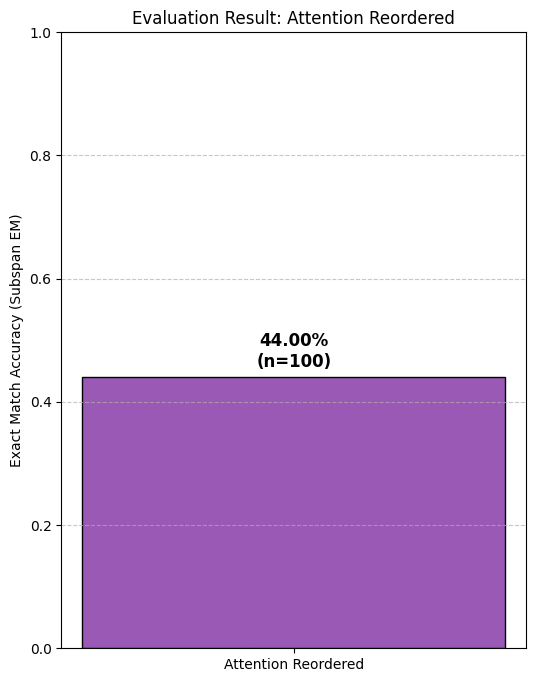

--- Attention Reordered ---
Total Samples: 100
Overall Accuracy: 44.00%


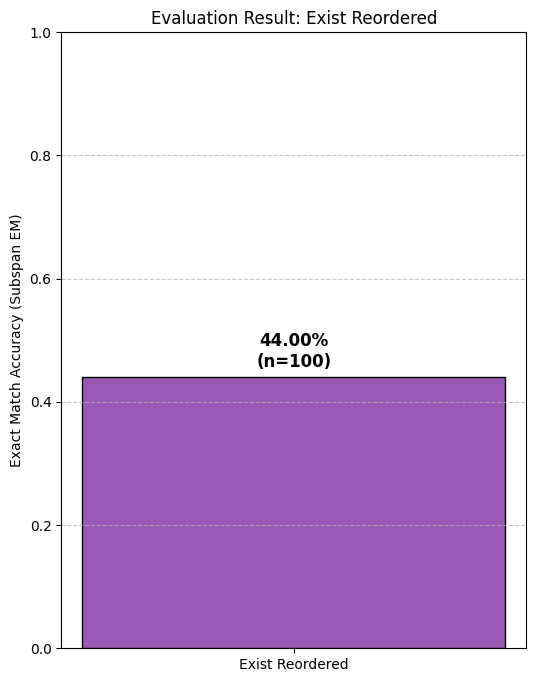

--- Exist Reordered ---
Total Samples: 100
Overall Accuracy: 44.00%


In [7]:
import json
import numpy as np
import matplotlib.pyplot as plt
from xopen import xopen

def evaluate_other_experiment_accuracy(dataset_path, result_path, title="Experiment Accuracy"):
    """
    データセットと実験結果をインデックスで照合し、精度を算出・表示する
    """
    em_scores = []

    # データセット(正解入り)と実験結果(回答のみ)を同時に開く
    # xopenを使うことで.gz形式にも対応
    with xopen(dataset_path, "r") as f_data, open(result_path, "r") as f_res:
        for i, (line_data, line_res) in enumerate(zip(f_data, f_res)):
            if i >= 100 : continue
            data = json.loads(line_data)
            res = json.loads(line_res)

            # データセット側の正解を取得 (キーは "answers")
            ground_truths = data.get("answers", [])
            # 実験結果側のモデル出力を取得 (キーは "answer")
            prediction = res.get("answer", "")

            # 正解判定
            score = best_subspan_em(prediction, ground_truths)
            em_scores.append(score)

    if not em_scores:
        print("エラー: 評価対象のデータが見つかりませんでした。")
        return 0.0

    # 平均精度の計算
    overall_accuracy = np.mean(em_scores)
    total_samples = len(em_scores)

    # --- 可視化 ---
    plt.figure(figsize=(6, 8))

    # 全体精度の棒グラフ
    color = '#9b59b6' # 紫系の色
    plt.bar([title], [overall_accuracy], color=color, edgecolor='black', width=0.5)

    # グラフ上に数値を表示
    plt.text(0, overall_accuracy + 0.01, f'{overall_accuracy:.2%}\n(n={total_samples})',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.title(f'Evaluation Result: {title}')
    plt.ylabel('Exact Match Accuracy (Subspan EM)')
    plt.ylim(0, 1.0) # 0% ~ 100%
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

    print(f"--- {title} ---")
    print(f"Total Samples: {total_samples}")
    print(f"Overall Accuracy: {overall_accuracy:.2%}")

    return overall_accuracy

# 使い方例
NQ_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/PositionalHidden/experiments/NQ/qa_data/20_total_documents/nq-open-20_total_documents_gold_at_0.jsonl.gz"

baseline_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/result_baseline.jsonl"
exist_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/result_scaled.jsonl"
acc_attn = evaluate_other_experiment_accuracy(NQ_path, baseline_path, title="Attention Reordered")
acc_exist = evaluate_other_experiment_accuracy(NQ_path, exist_path, title="Exist Reordered")

In [ ]:
import json
from pathlib import Path

def compare_jsonl_questions(path_baseline, path_experiment, limit=200):
    """
    2つのJSONLファイルを読み込み、先頭N件の 'question' フィールドの一致を確認する
    """
    def load_questions_limited(file_path, n):
        questions = []
        path = Path(file_path)
        if not path.exists():
            print(f"Error: ファイルが見つかりません -> {file_path}")
            return None

        with open(path, 'r', encoding='utf-8') as f:
            for i, line in enumerate(f):
                if i >= n: # 指定件数に達したら終了
                    break
                try:
                    data = json.loads(line)
                    if 'question' in data:
                        questions.append(data['question'])
                except json.JSONDecodeError:
                    print(f"Error: {file_path} の {i+1}行目が不正です。")
        return questions

    print(f"--- 整合性チェック（先頭{limit}件）開始 ---")
    q_base = load_questions_limited(path_baseline, limit)
    q_exp = load_questions_limited(path_experiment, limit)

    if q_base is None or q_exp is None:
        return

    # 実際の読み込み件数を確認
    count_base, count_exp = len(q_base), len(q_exp)

    # 1. 読み込み件数の不一致チェック
    if count_base != count_exp:
        print(f"⚠️ 読み込み件数が異なります（データ不足の可能性）: Baseline({count_base}) vs Exp({count_exp})")
    else:
        print(f"✅ 両ファイルとも {count_base} 件読み込みました。")

    # 2. 完全一致の確認
    if q_base == q_exp:
        print(f"✅ 先頭 {count_base} 件の質問の「内容」と「順序」が完全に一致しています。")
    else:
        print(f"❌ 先頭 {count_base} 件の中で不一致が発見されました。")

        # どの行でズレ始めたか特定
        for idx, (b, e) in enumerate(zip(q_base, q_exp)):
            if b != e:
                print(f"\n[不一致箇所: {idx + 1}行目]")
                print(f"Baseline: {b[:50]}...")
                print(f"Exp     : {e[:50]}...")
                break

    print(f"--- チェック完了 ---")

baseline_path = "/content/drive/MyDrive/Colab_Notebooks/graduate_research/Logs/NQ/result_baseline.jsonl"
compare_jsonl_questions(OUTPUT_PATH, baseline_path)

--- 整合性チェック（先頭200件）開始 ---
✅ 両ファイルとも 200 件読み込みました。
✅ 先頭 200 件の質問の「内容」と「順序」が完全に一致しています。
--- チェック完了 ---


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

def run_batch_inference(model_name, texts, batch_size=2):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    # パディングトークンが設定されていないモデル（Llamaなど）のために設定
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16,
        device_map="auto"
    )

    results = []

    # 2. 指定したバッチサイズでループ
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]

        # 3. テンソル化（パディングと切り捨てを同時に行う）
        inputs = tokenizer(
            batch_texts,
            return_tensors="pt",
            padding=True,         # バッチ内の最大長に合わせる
            truncation=True,      # モデルの最大長を超える場合は切り捨てる
            max_length=512        # 必要に応じて長さを制限
        ).to(model.device)

        # 4. 推論実行
        with torch.no_grad():
            output_tokens = model.generate(
                **inputs,
                max_new_tokens=50,
                do_sample=False
            )

        # 5. デコードして結果を格納
        batch_outputs = tokenizer.batch_decode(output_tokens, skip_special_tokens=True)
        results.extend(batch_outputs)

    return results

    def test_batch_logic():
    # サンプルデータ
    test_input = [
        "Python is a",
        "The capital of Japan is",
        "Artificial intelligence will"
    ]

    # ダミーのトークナイザー設定（実際の挙動をシミュレート）
    from transformers import GPT2Tokenizer
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token

    print("--- Testing Tokenization Batching ---")
    # バッチサイズ2でシミュレーション
    batch = test_input[:2]
    encoded = tokenizer(batch, padding=True, return_tensors="pt")

    # 形状の確認
    # [Batch Size, Sequence Length]
    shape = encoded["input_ids"].shape
    print(f"Input Shape: {shape}")
    print(f"Attention Mask: \n{encoded['attention_mask']}")

    assert shape[0] == 2, "Batch size mismatch"
    assert encoded["input_ids"].shape == encoded["attention_mask"].shape, "Mask shape mismatch"
    print("\n✅ Test Passed: Padding and Masking logic is correct.")

# 実行
# test_batch_logic()